In [9]:
# will use run 5234857690020 as an example



In [3]:
library(stringr)
library(rjson)
library(ggplot2)
library(viridis)

Loading required package: viridisLite



In [11]:
all_rf_files <- list.files(file.path('output', 'rf_dist_files', 5234857690020))

In [12]:
all_rf_files

[1] "processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt"
[2] "processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_4_TERMINAL_rf_dist_res.txt"
[3] "processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_1_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt"  
[4] "processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_1_moretargetslowerrates_time_4_TERMINAL_rf_dist_res.txt"

Warning message in readLines(testfile, n = 2):
“incomplete final line found on 'output/rf_dist_files/5234857690020/processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt'”


In [34]:
testfile <- file.path('output', 'rf_dist_files', 5234857690020, 
                      'processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt')
first_two_lines <- readLines(testfile, n = 2)
rf_dist <- as.numeric(first_two_lines[1])
json_path <- first_two_lines[2]
input_arg_params <- fromJSON(file = json_path)
input_arg_df <- data.frame(t(do.call(rbind, input_arg_params)))

Warning message in readLines(testfile, n = 2):
“incomplete final line found on 'output/rf_dist_files/5234857690020/processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt'”


In [36]:
input_arg_df

num_init_cells,sim_length,num_cores,cell_cycle_length,time_inc,max_mito_genomes_per_cell,bc_length,max_bc_ints_per_cell,mito_genome_length,nuc_target_config,⋯,bc_nuc_composition,mt_substitution_model,mt_sub_model_params,mt_invariant_sites,mt_nontarget_heterogeneity_gamma,bc_substitution_model,bc_sub_model_params,bc_invariant_sites,bc_nontarget_heterogeneity_gamma,jitter_fraction
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0.25; 0.25; 0.3; 0.2,HKY,3; 0.00000000003; 0.00000000001,0.05,0.5; 3; mean,HKY,3; 0.000000000000000000003; 0.0000000000000000000001,0,0.5; 3; mean,0.05


In [35]:
input_arg_params 

$num_init_cells
[1] 1

$sim_length
[1] "3:4:1"

$num_cores
[1] 10

$cell_cycle_length
[1] 1

$time_inc
[1] 0.5

$max_mito_genomes_per_cell
[1] "1"

$bc_length
[1] 300

$max_bc_ints_per_cell
[1] "10"

$variable_bc_ints_per_cell
NULL

$mito_genome_length
[1] 16569

$be_target_config
NULL

$nuc_target_config
[1] "R"

$force_transversions
[1] TRUE

$be_targets
NULL

$be_editing_window
[1] 0

$be_decaying_window
[1] FALSE

$nuclease_targets
[1] "15:0.33;0.33;0.34"

$nuclease_editing_window
[1] 1

$nuclease_decaying_window
[1] TRUE

$bc_bg_indel_probs
[1] "0.00000000000000000000001; 0.00000000000000000000000003"

$mt_bg_indel_probs
[1] "0.0000000001; 0.0000000003"

$be_mutations_per_target_per_division
[1] 0.01

$nuc_insertions_per_target_per_division
[1] 0.03

$nuc_deletions_per_target_per_division
[1] 0.01

$savename
[1] "moretargetslowerrates"

$reconstruction_method
[1] "fasta_only"

$include_var_pos_fasta
[1] FALSE

$chosen_gamma
[1] "mt_gamma_site_model"

$score_approach
[1] "af; bin"

$fasta_type
[1] "terminal"

$sampling_fractions
[1] "0.8; 1"

$mt_allelic_fractions
[1] "0"

$bc_allelic_fractions
[1] "0"

$filter_binary_with_af
[1] TRUE

$mt_genome_recovery_prob
[1] 0.85

$bc_integration_recovery_prob
[1] 1

$recon_modality
[1] "bc; mt; integrated"

$add_mito_jitter
[1] FALSE

$barcode_sequence
NULL

$plot_heatmaps
[1] FALSE

$be_conversion_pattern
[1] "C --> T"

$bc_nuc_composition
[1] "0.25; 0.25; 0.3; 0.2"

$mt_substitution_model
[1] "HKY"

$mt_sub_model_params
[1] "3; 0.00000000003; 0.00000000001"

$mt_invariant_sites
[1] 0.05

$mt_nontarget_heterogeneity_gamma
[1] "0.5; 3; mean"

$bc_substitution_model
[1] "HKY"

$bc_sub_model_params
[1] "3; 0.000000000000000000003; 0.0000000000000000000001"

$bc_invariant_sites
[1] 0

$bc_nontarget_heterogeneity_gamma
[1] "0.5; 3; mean"

$jitter_fraction
[1] 0.05

In [22]:
json_path

[1] "sim5_params/nuclease_test_len3_4_decaying_window1_nomt.json"

In [23]:
getwd()

[1] "/dartfs/rc/lab/M/McKennaLab/projects/Aidan/simulations/r_sim_clean"

In [16]:
lines <- readLines(testfile, n = 2)

Warning message in readLines(testfile, n = 2):
“incomplete final line found on 'output/rf_dist_files/5234857690020/processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt'”


In [17]:
lines

[1] "0.75"                                                       
[2] "sim5_params/nuclease_test_len3_4_decaying_window1_nomt.json"

In [14]:
rf_dist

[1] "0.75"

In [7]:
make_results_df <- function(urid){

    # helper func for downstream processing of this dataframe
    # split vals by semicolon (and colon, if necessary for target specs)
    split_vals <- function(joined_val, outputted_type = 'numeric'){
      no_spaces <- str_replace_all(joined_val, ' ', '')

      # replace colons with semicolons (for target specification, if necessary)
      no_spaces <- str_replace_all(no_spaces, ':', ';')
      fracs <- unlist(str_split(no_spaces, pattern = ';'))
      
      if(outputted_type == 'numeric'){
        fracs <- as.numeric(fracs)
      }
      else if((outputted_type == 'integer') | (outputted_type == 'int')){
        fracs <- as.integer(fracs)
      }
      
      return(fracs)
    }

    

    if(!dir.exists(file.path('output', 'param_results_files', urid))){
        dir.create(file.path('output', 'param_results_files', urid), recursive = TRUE)
    }
    
    growing_list_of_dfs <- list()

    all_rf_files <- list.files(file.path('output', 'rf_dist_files', urid))

    for(i in seq_len(length(all_rf_files))){
    
        file_name <- all_rf_files[i]
        
        path_to_file <- file.path('output', 'rf_dist_files', urid, file_name)
    
        current_timepoint <- str_extract(file_name, 
                                     '(?<=_time_)[0-9.]+')
        bc_or_mt <- str_extract(string = file_name, 
                                pattern = '(?<=processed_)(mt|bc)(?=_list)')
        num_ints <- as.integer(str_extract(string = file_name, 
                                                   pattern = '(?<=_list_)\\d+'))
        cell_rec_rate <- str_extract(file_name, 
                                         '(?<=_cell_rec_rate_)[0-9.]+')
        int_recovery_prob <- str_extract(file_name, 
                                         '(?<=_recovery_prob_)[0-9.]+')
    
        first_two_lines <- readLines(path_to_file, n = 2)
        rf_dist <- as.numeric(first_two_lines[1])
        accuracy <- 1-rf_dist
    
        sub_df <- data.frame('timepoint' = current_timepoint, 
                         'bc_or_mt' = bc_or_mt,
                         'num_ints' = num_ints,
                         'cell_rec_rate' = cell_rec_rate,
                         'int_recovery_prob' = int_recovery_prob,
                            'norm_rf_dist' = rf_dist,
                            'accuracy' = accuracy)
    
        
        json_path <- first_two_lines[2]
        input_arg_params <- fromJSON(file = json_path)
        input_arg_df <- data.frame(t(do.call(rbind, input_arg_params)))
    
        merged_df <- data.frame(cbind(input_arg_df, sub_df))
    
        
        growing_list_of_dfs[[i]] <- merged_df
        
        
    }
    
    stacked_results_df <- data.frame(do.call(rbind, growing_list_of_dfs))

    # some downstream processing/formatting ... 

    # break bc bg indel probs into separate cols:
    bc_bg_indel_splits <- lapply(stacked_results_df$bc_bg_indel_probs, function(x){
      split_vals(x, 'numeric')
    })
    bc_bg_insertion_prob <- sapply(bc_bg_indel_splits, function(x){return(x[1])})  
    bc_bg_deletion_prob <- sapply(bc_bg_indel_splits, function(x){return(x[2])}) 
    stacked_results_df$bc_bg_insertion_prob <- bc_bg_insertion_prob
    stacked_results_df$bc_bg_deletion_prob <- bc_bg_deletion_prob

    # break mt bg indel probs into separate cols:
    mt_bg_indel_splits <- lapply(stacked_results_df$mt_bg_indel_probs, function(x){
      split_vals(x, 'numeric')
    })
    mt_bg_insertion_prob <- sapply(mt_bg_indel_splits, function(x){return(x[1])})  
    mt_bg_deletion_prob <- sapply(mt_bg_indel_splits, function(x){return(x[2])}) 
    stacked_results_df$mt_bg_insertion_prob <- mt_bg_insertion_prob
    stacked_results_df$mt_bg_deletion_prob <- mt_bg_deletion_prob
    
    # break nuclease target spec into different columns, if necessary:
    # 'nuclease_targets' will not be in df if no targets were specified
    if('nuclease_targets' %in% colnames(stacked_results_df)){

        # HAVE TO ACCOUNT FOR ALTERNATIVE SPECIFICATION SCHEMES LATER
        if(grepl(pattern = ';', x = stacked_results_df$nuclease_targets[1])){
        
            nuc_targets_splits <- lapply(stacked_results_df$nuclease_targets, function(x){
              split_vals(x, 'numeric')
            })
            num_nuc_targets <- sapply(nuc_targets_splits, function(x){return(x[1])})  
            frac_nuc_targets_h <- sapply(nuc_targets_splits, function(x){return(x[2])}) 
            frac_nuc_targets_m <- sapply(nuc_targets_splits, function(x){return(x[3])}) 
            frac_nuc_targets_l <- sapply(nuc_targets_splits, function(x){return(x[4])}) 
            stacked_results_df$num_nuc_targets <- num_nuc_targets
            stacked_results_df$frac_nuc_targets_h <- frac_nuc_targets_h
            stacked_results_df$frac_nuc_targets_m <- frac_nuc_targets_m
            stacked_results_df$frac_nuc_targets_l <- frac_nuc_targets_l
        }
    }
    

    # break BE target spec into different columns, if necessary:
    # 'be_targets' will not be in df if no targets were specified
    if('be_targets' %in% colnames(stacked_results_df)){

        # HAVE TO ACCOUNT FOR ALTERNATIVE SPECIFICATION SCHEMES LATER
        if(grepl(pattern = ';', x = stacked_results_df$be_targets[1])){
        
            be_targets_splits <- lapply(stacked_results_df$be_targets, function(x){
              split_vals(x, 'numeric')
            })
            num_be_targets <- sapply(be_targets_splits, function(x){return(x[1])})  
            frac_be_targets_h <- sapply(be_targets_splits, function(x){return(x[2])}) 
            frac_be_targets_m <- sapply(be_targets_splits, function(x){return(x[3])}) 
            frac_be_targets_l <- sapply(be_targets_splits, function(x){return(x[4])}) 
            stacked_results_df$num_be_targets <- num_be_targets
            stacked_results_df$frac_be_targets_h <- frac_be_targets_h
            stacked_results_df$frac_be_targets_m <- frac_be_targets_m
            stacked_results_df$frac_be_targets_l <- frac_be_targets_l
        }
    }

    # convert appropriate cols to numeric if they are present
    numeric_cols <- c('timepoint', 'num_ints', 'cell_rec_rate', 'int_recovery_prob',
                      'be_editing_window',
                 'be_mutations_per_target_per_division', 'nuc_insertions_per_target_per_division',
                 'nuc_deletions_per_target_per_division', 'mt_invariant_sites', 'bc_invariant_sites', 'jitter_fraction',
                 'cell_cycle_length', 
                      'bc_bg_insertion_prob', 'mt_bg_insertion_prob', 'bc_bg_deletion_prob', 'bc_bg_deletion_prob',
                     'num_nuc_targets', 'frac_nuc_targets_h', 'frac_nuc_targets_m', 'frac_nuc_targets_l',
                     'num_be_targets', 'frac_be_targets_h', 'frac_be_targets_m', 'frac_be_targets_l')

    for(col in numeric_cols){
        if(col %in% colnames(stacked_results_df)){
            stacked_results_df[, col] <- sapply(stacked_results_df[, col], as.numeric)
        }
    }
    
    write.csv(stacked_results_df, file.path('output', 'param_results_files', urid, 'stacked_results.csv'))

    return(stacked_results_df)
}



In [121]:
res_7462390024195 <- make_results_df(7462390024195)


In [62]:
res_7462390024195

num_init_cells,sim_length,num_cores,cell_cycle_length,time_inc,max_mito_genomes_per_cell,bc_length,max_bc_ints_per_cell,mito_genome_length,nuc_target_config,⋯,bc_invariant_sites,bc_nontarget_heterogeneity_gamma,jitter_fraction,timepoint,bc_or_mt,num_ints,cell_rec_rate,int_recovery_prob,norm_rf_dist,accuracy
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0,0.5; 3; mean,0.05,3,bc,10,0.8,1,0.0000000,1.0000000
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0,0.5; 3; mean,0.05,4,bc,10,0.8,1,0.4000000,0.6000000
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0,0.5; 3; mean,0.05,3,bc,10,1,1,0.0000000,1.0000000
1,3:4:1,10,1,0.5,1,300,10,16569,R,⋯,0,0.5; 3; mean,0.05,4,bc,10,1,1,0.1538462,0.8461538


In [93]:
splits <- lapply(res_7462390024195$bc_bg_indel_probs, function(x){
  split_vals(x, 'numeric')
})

bc_bg_insertion_prob <- sapply(splits, function(x){return(x[1])})  
bc_bg_deletion_prob <- sapply(splits, function(x){return(x[2])})  

In [105]:



print(bc_bg_insertion_prob)  
print(bc_bg_deletion_prob)  


[1] 1e-23 1e-23 1e-23 1e-23
[1] 3e-26 3e-26 3e-26 3e-26


In [94]:
class(splits)

[1] "list"

In [95]:
class(splits[[1]])

[1] "numeric"

In [97]:
length(splits[[1]])

[1] 2

[1] "15:0.33;0.33;0.34"

[1] TRUE

In [90]:
res_7462390024195 <- make_results_df(7462390024195)
res_7462390024195$bc_bg_insertion_prob <-
res_7462390024195$bc_bg_deletion_prob <-




[1] "0.00000000000000000000001; 0.00000000000000000000000003"
[2] "0.00000000000000000000001; 0.00000000000000000000000003"
[3] "0.00000000000000000000001; 0.00000000000000000000000003"
[4] "0.00000000000000000000001; 0.00000000000000000000000003"

In [111]:
res_7462390024195 <- make_results_df(7462390024195)


numeric_cols <- c('timepoint', 'num_ints', 'cell_rec_rate', 'int_recovery_prob',
                      'be_editing_window', 'bc_bg_indel_probs',
                 'mt_bg_indel_probs', 'be_mutations_per_target_per_division', 'nuc_insertions_per_target_per_division',
                 'nuc_deletions_per_target_per_division', 'mt_invariant_sites', 'bc_invariant_sites', 'jitter_fraction',
                 'cell_cycle_length')
for(col in numeric_cols){
    print(paste0('col == ', col))
    res_7462390024195[, col] <- sapply(res_7462390024195[, col], as.numeric)
}


[1] "col == timepoint"
[1] "col == num_ints"
[1] "col == cell_rec_rate"
[1] "col == int_recovery_prob"
[1] "col == be_editing_window"
[1] "col == bc_bg_indel_probs"


Warning message in lapply(X = X, FUN = FUN, ...):
“NAs introduced by coercion”
Warning message in lapply(X = X, FUN = FUN, ...):
“NAs introduced by coercion”
Warning message in lapply(X = X, FUN = FUN, ...):
“NAs introduced by coercion”
Warning message in lapply(X = X, FUN = FUN, ...):
“NAs introduced by coercion”


[1] "col == mt_bg_indel_probs"


Warning message in lapply(X = X, FUN = FUN, ...):
“NAs introduced by coercion”
Warning message in lapply(X = X, FUN = FUN, ...):
“NAs introduced by coercion”
Warning message in lapply(X = X, FUN = FUN, ...):
“NAs introduced by coercion”
Warning message in lapply(X = X, FUN = FUN, ...):
“NAs introduced by coercion”


[1] "col == be_mutations_per_target_per_division"
[1] "col == nuc_insertions_per_target_per_division"
[1] "col == nuc_deletions_per_target_per_division"
[1] "col == mt_invariant_sites"
[1] "col == bc_invariant_sites"
[1] "col == jitter_fraction"
[1] "col == cell_cycle_length"


In [76]:
sapply(res_7462390024195, class)

num_init_cells                             sim_length 
                           "character"                            "character" 
                             num_cores                      cell_cycle_length 
                           "character"                            "character" 
                              time_inc              max_mito_genomes_per_cell 
                           "character"                            "character" 
                             bc_length                   max_bc_ints_per_cell 
                           "character"                            "character" 
                    mito_genome_length                      nuc_target_config 
                           "character"                            "character" 
                   force_transversions                      be_editing_window 
                           "character"                            "character" 
                    be_decaying_window                       nuclease_targets 
                           "character"                            "character" 
               nuclease_editing_window               nuclease_decaying_window 
                           "character"                            "character" 
                     bc_bg_indel_probs                      mt_bg_indel_probs 
                           "character"                            "character" 
  be_mutations_per_target_per_division nuc_insertions_per_target_per_division 
                           "character"                            "character" 
 nuc_deletions_per_target_per_division                               savename 
                           "character"                            "character" 
                 reconstruction_method                  include_var_pos_fasta 
                           "character"                            "character" 
                          chosen_gamma                         score_approach 
                           "character"                            "character" 
                            fasta_type                     sampling_fractions 
                           "character"                            "character" 
                  mt_allelic_fractions                   bc_allelic_fractions 
                           "character"                            "character" 
                 filter_binary_with_af                mt_genome_recovery_prob 
                           "character"                            "character" 
          bc_integration_recovery_prob                         recon_modality 
                           "character"                            "character" 
                       add_mito_jitter                          plot_heatmaps 
                           "character"                            "character" 
                 be_conversion_pattern                     bc_nuc_composition 
                           "character"                            "character" 
                 mt_substitution_model                    mt_sub_model_params 
                           "character"                            "character" 
                    mt_invariant_sites       mt_nontarget_heterogeneity_gamma 
                           "character"                            "character" 
                 bc_substitution_model                    bc_sub_model_params 
                           "character"                            "character" 
                    bc_invariant_sites       bc_nontarget_heterogeneity_gamma 
                           "character"                            "character" 
                       jitter_fraction                              timepoint 
                           "character"                            "character" 
                              bc_or_mt                               num_ints 
                           "character"                              "integer" 
                         cell_rec_rate                      int_recovery_p

In [ ]:
# params of interest:

# within each figure ...
# time, cell_recovery_rate, int_recovery_prob

# 

In [8]:
res_7462390024195 <- make_results_df(7462390024195)


Warning message in file(con, "r"):
“cannot open file 'sim5_params/nuclease_test_len3_4_decaying_window1_nomt.json': No such file or directory”


ERROR: Error in file(con, "r"): cannot open the connection


In [27]:
res_3295570239254 <- make_results_df(3295570239254)

In [ ]:
# there will be one heatmap for each 

Saving 7 x 7 in image


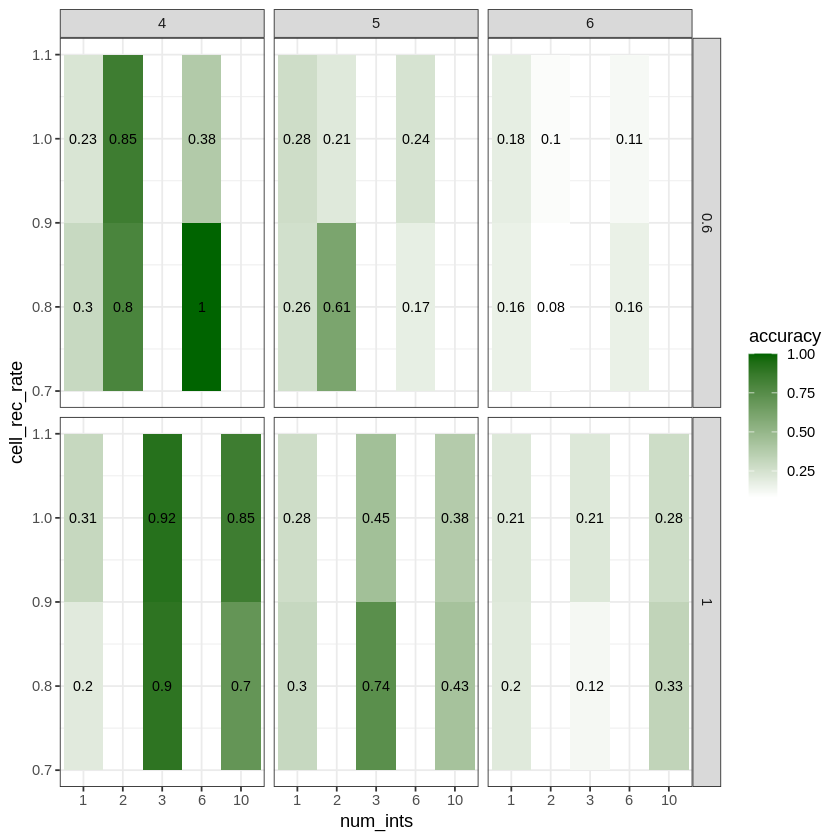

In [29]:
res_3295570239254$num_ints <- factor(res_3295570239254$num_ints, levels = c('1', '2', '3', '6', '10'))
ggplot(res_3295570239254, aes(x = num_ints, y = cell_rec_rate, fill = accuracy)) +
  geom_tile() +
  geom_text(aes(label = round(accuracy, 2)), color = "black", size = 3) +
  scale_fill_gradient(low = 'white', high = 'darkgreen') +
  theme_bw() + 
  facet_grid(int_recovery_prob ~ timepoint)  # Facet by Group1 (rows) and Group2 (columns)

ggsave('./ex_fig3.png')

In [28]:
print(res_3295570239254$num_nuc_targets)


 [1] 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20 20
[26] 20 20 20 20 20 20 20 20 20 20 20


In [26]:
print(res_8599176025223$num_nuc_targets)


 [1] 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50
[26] 50 50 50 50 50 50 50 50 50 50 50


In [24]:
print(res_8599176025223$nuc_deletions_per_target_per_division)
print(res_2250829045941$nuc_deletions_per_target_per_division)


 [1] 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03
[16] 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03 0.03
[31] 0.03 0.03 0.03 0.03 0.03 0.03
 [1] 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003
[13] 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003
[25] 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003 0.003


Saving 7 x 7 in image


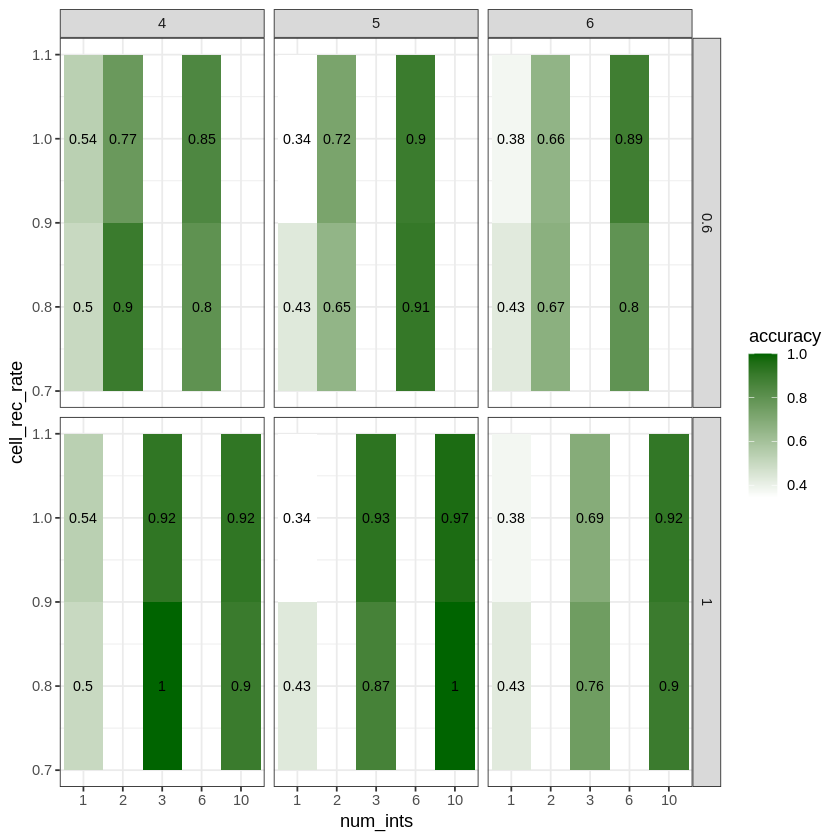

In [21]:
res_8599176025223 <- make_results_df(8599176025223)
res_8599176025223$num_ints <- factor(res_8599176025223$num_ints, levels = c('1', '2', '3', '6', '10'))
ggplot(res_8599176025223, aes(x = num_ints, y = cell_rec_rate, fill = accuracy)) +
  geom_tile() +
  geom_text(aes(label = round(accuracy, 2)), color = "black", size = 3) +
  scale_fill_gradient(low = 'white', high = 'darkgreen') +
  theme_bw() + 
  facet_grid(int_recovery_prob ~ timepoint)  # Facet by Group1 (rows) and Group2 (columns)

ggsave('./ex_fig.png')

Saving 7 x 7 in image


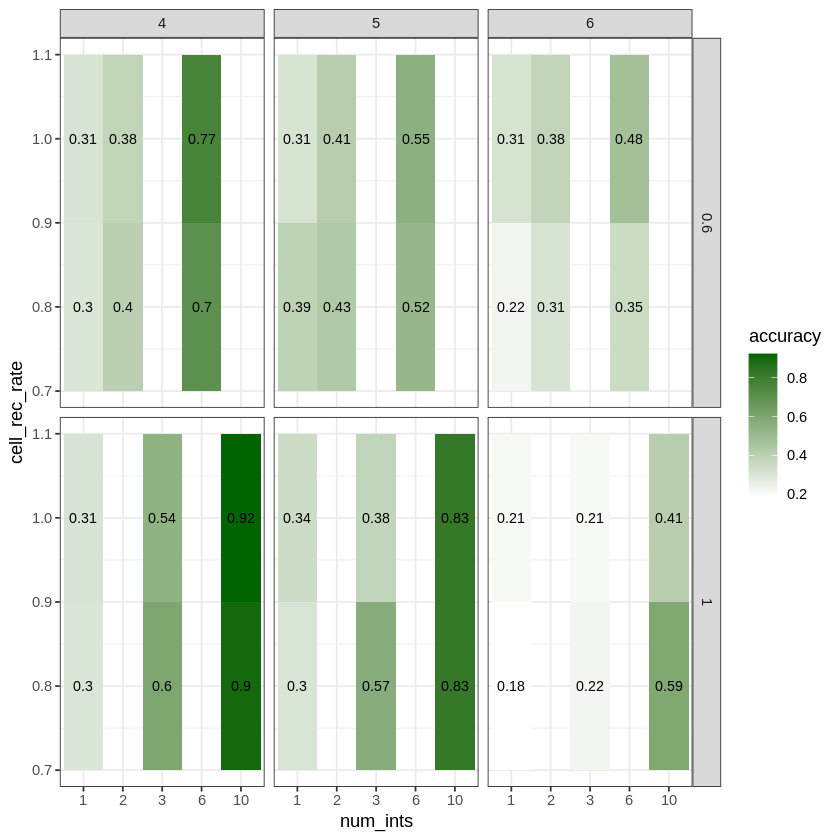

In [20]:
res_2250829045941 <- make_results_df(2250829045941)
res_2250829045941$num_ints <- factor(res_2250829045941$num_ints, levels = c('1', '2', '3', '6', '10'))
ggplot(res_2250829045941, aes(x = num_ints, y = cell_rec_rate, fill = accuracy)) +
  geom_tile() +
  geom_text(aes(label = round(accuracy, 2)), color = "black", size = 3) +
  scale_fill_gradient(low = 'white', high = 'darkgreen') +
  theme_bw() + 
  facet_grid(int_recovery_prob ~ timepoint)  # Facet by Group1 (rows) and Group2 (columns)

ggsave('./ex_fig_2.png')

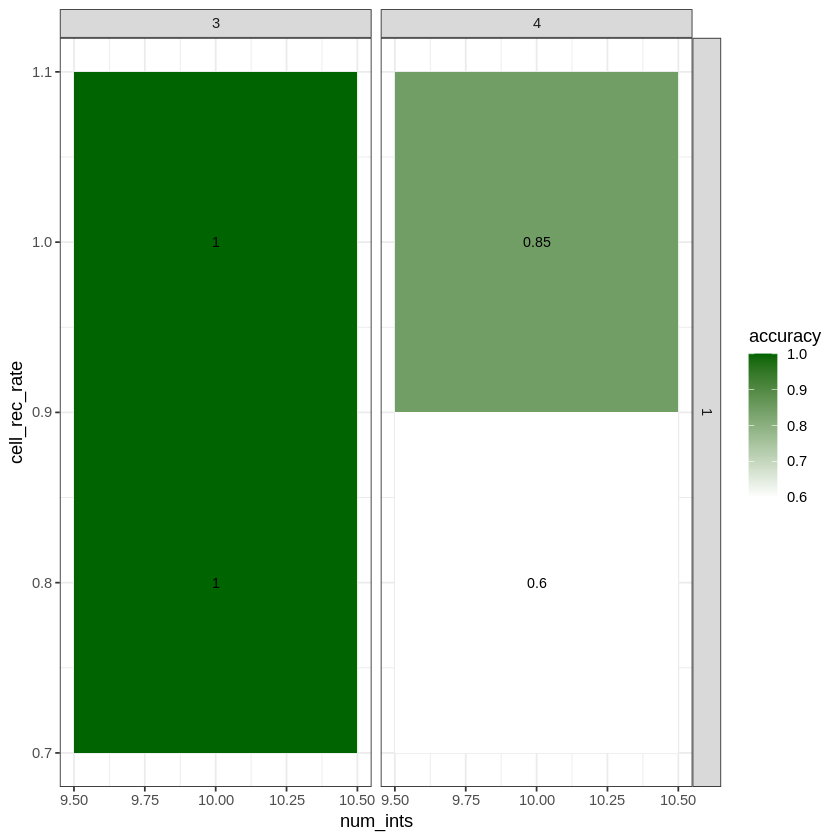

In [135]:
res_7462390024195 <- make_results_df(7462390024195)
ggplot(res_7462390024195, aes(x = num_ints, y = cell_rec_rate, fill = accuracy)) +
  geom_tile() +
  geom_text(aes(label = round(accuracy, 2)), color = "black", size = 3) +
  scale_fill_gradient(low = 'white', high = 'darkgreen') +
  theme_bw() + 
  facet_grid(int_recovery_prob ~ timepoint)  # Facet by Group1 (rows) and Group2 (columns)

In [78]:
res_8238399424377

num_init_cells,sim_length,num_cores,cell_cycle_length,time_inc,max_mito_genomes_per_cell,bc_length,max_bc_ints_per_cell,mito_genome_length,nuc_target_config,⋯,bc_invariant_sites,bc_nontarget_heterogeneity_gamma,jitter_fraction,timepoint,bc_or_mt,num_ints,cell_rec_rate,int_recovery_prob,norm_rf_dist,accuracy
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>
1,3:4:1,10,1,0.5,1,300,5; 10,16569,R,⋯,0,0.5; 3; mean,0.05,3,bc,10,0.8,1,0.5000000,0.5000000
1,3:4:1,10,1,0.5,1,300,5; 10,16569,R,⋯,0,0.5; 3; mean,0.05,4,bc,10,0.8,1,0.4000000,0.6000000
1,3:4:1,10,1,0.5,1,300,5; 10,16569,R,⋯,0,0.5; 3; mean,0.05,3,bc,10,1,1,0.4000000,0.6000000
1,3:4:1,10,1,0.5,1,300,5; 10,16569,R,⋯,0,0.5; 3; mean,0.05,4,bc,10,1,1,0.3076923,0.6923077


In [5]:
make_heatmap <- function(run_id){
    res <- make_results_df(run_id)
    
    int_breaks <- unique(res$num_ints)
    p <- ggplot(res, aes(x = num_ints, y = cell_rec_rate, fill = accuracy)) +
      geom_tile() +
      scale_x_continuous(breaks = int_breaks) + 
      geom_text(aes(label = round(accuracy, 2)), color = "black", size = 3) +
      scale_fill_gradient(low = 'white', high = 'darkgreen') +
      theme_bw() + 
      facet_grid(timepoint ~ int_recovery_prob)  # Facet by Group1 (rows) and Group2 (columns)

    ggsave(file.path('output', 'param_results_files', run_id, 'rf_heatmap.png'))
}

In [11]:
res_8599176025223

num_init_cells,sim_length,num_cores,cell_cycle_length,time_inc,max_mito_genomes_per_cell,bc_length,max_bc_ints_per_cell,mito_genome_length,nuc_target_config,⋯,norm_rf_dist,accuracy,bc_bg_insertion_prob,bc_bg_deletion_prob,mt_bg_insertion_prob,mt_bg_deletion_prob,num_nuc_targets,frac_nuc_targets_h,frac_nuc_targets_m,frac_nuc_targets_l
<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.50000000,0.5000000,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.56521739,0.4347826,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.57142857,0.4285714,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.46153846,0.5384615,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.65517241,0.3448276,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.62295082,0.3770492,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.50000000,0.5000000,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.56521739,0.4347826,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34
1,4:6:1,10,1,0.5,1,300,1;3;10,50,R,⋯,0.57142857,0.4285714,1e-23,3e-26,1e-10,3e-10,50,0.33,0.33,0.34


In [12]:
res_8599176025223$num_ints

[1]  1  1  1  1  1  1  1  1  1  1  1  1 10 10 10 10 10 10  2  2  2  2  2  2  3
[26]  3  3  3  3  3  6  6  6  6  6  6

In [9]:
make_heatmap(8599176025223)

Saving 7 x 7 in image


In [136]:
make_heatmap(9355775554426)

Saving 7 x 7 in image


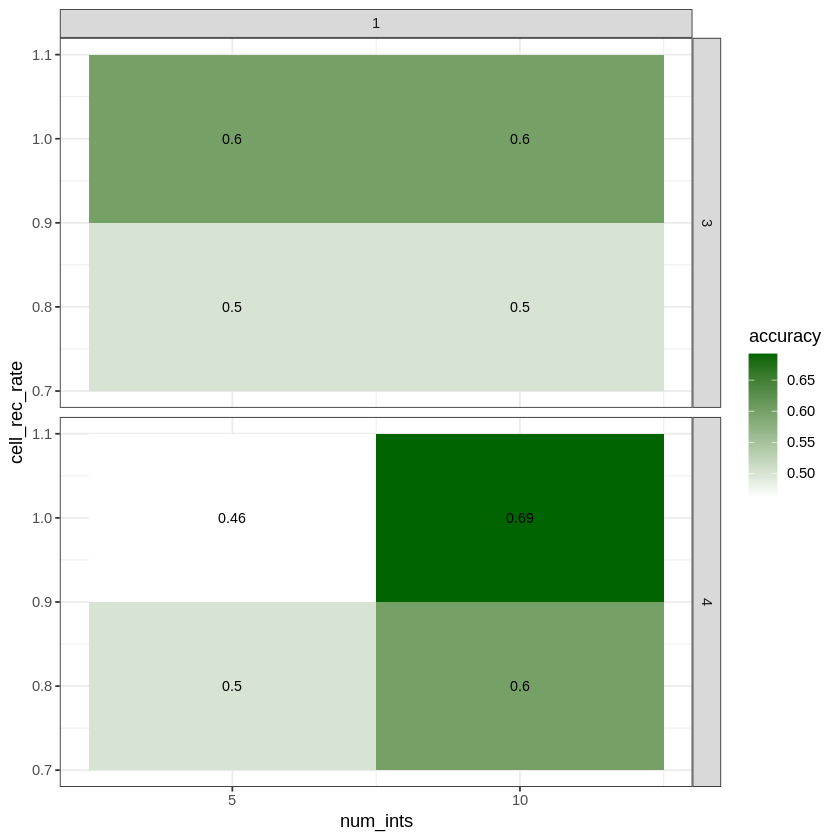

In [129]:
res_8238399424377 <- make_results_df(8238399424377)

int_breaks <- unique(res_8238399424377$num_ints)
ggplot(res_8238399424377, aes(x = num_ints, y = cell_rec_rate, fill = accuracy)) +
  geom_tile() +
  scale_x_continuous(breaks = int_breaks) + 
  geom_text(aes(label = round(accuracy, 2)), color = "black", size = 3) +
  scale_fill_gradient(low = 'white', high = 'darkgreen') +
  theme_bw() + 
  facet_grid(timepoint ~ int_recovery_prob)  # Facet by Group1 (rows) and Group2 (columns)

In [ ]:
# first line of each txt file has the rf dist
# second line has the path to the parameter file used


In [ ]:
# extract bc/mt, num_ints, integration recovery prob, cell recovery rate, and timepoint from the name of the file (since these vary in the param file)


In [31]:
(current_timepoint <- str_extract('processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                                 '(?<=_time_)[0-9.]+'))
(bc_or_mt <- str_extract(string = 'processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                        pattern = '(?<=processed_)(mt|bc)(?=_list)'))
(num_ints <- as.integer(str_extract(string = 'processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                                           pattern = '(?<=_list_)\\d+')))
(cell_rec_rate <- str_extract('processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                                 '(?<=_cell_rec_rate_)[0-9.]+'))
(int_recovery_prob <- str_extract('processed_bc_list_10_integrations_recovery_prob_1_cell_rec_rate_0.8_moretargetslowerrates_time_3_TERMINAL_rf_dist_res.txt', 
                                 '(?<=_recovery_prob_)[0-9.]+'))



[1] "3"

[1] "bc"

[1] 10

[1] "0.8"

[1] "1"

In [32]:
sub_df <- data.frame('timepoint' = current_timepoint, 
                     'bc_or_mt' = bc_or_mt,
                     'num_ints' = num_ints,
                     'cell_rec_rate' = cell_rec_rate,
                     'int_recovery_prob' = int_recovery_prob)

In [33]:
sub_df

timepoint,bc_or_mt,num_ints,cell_rec_rate,int_recovery_prob
<chr>,<chr>,<int>,<chr>,<chr>
3,bc,10,0.8,1


In [5]:
current_timepoint

[1] "3"